# 03A Discrete Choice DP: The Rust (1987) Model

[![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)

In [1]:
# === Environment Setup ===
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (11, 7), 'figure.dpi': 130})
%config InlineBackend.figure_format = 'retina'
np.set_printoptions(suppress=True, linewidth=120, precision=4)



Environment initialized.


### Table of Contents
1. [The Lens: Discrete Choices with Conditional Value Functions](#The-Lens:-Discrete-Choices-with-Conditional-Value-Functions)
2. [The Rust (1987) Model: Optimal Replacement](#The-Rust-(1987)-Model:-Optimal-Replacement)
3. [Summary](#Summary)

# The Lens: Discrete Choices with Conditional Value Functions

**What problem are we solving?**
Many economic decisions are discrete: replace or keep, work or retire, default or repay. These choices create kinks in the value function that break smooth optimization methods. We need a way to evaluate each discrete alternative while still accounting for optimal future behavior.

**Why this method?**
The **conditional value function** approach computes the value of each discrete choice separately and then takes the upper envelope. This makes discrete-choice dynamic programs tractable and leads to clear policy thresholds, as in Rust’s (1987) bus replacement model.

### Learning Objectives
* **Formulate** discrete-choice dynamic programs using conditional value functions.
* **Implement** value function iteration for the Rust optimal replacement model.
* **Interpret** replacement thresholds and policy functions.

### Prerequisites
* **`03-Economic-Modeling/01_Dynamic_Programming.ipynb`**: Bellman equation and VFI basics.
* **`02-Numerical-Methods/05_Optimization.ipynb`**: Optimization primitives.
* **Economics:** Discrete choice logic and dynamic incentives.

### 1. The Rust (1987) Model: Optimal Replacement

Rust's model provides a canonical example of a discrete choice DP problem. A manager, Harold Zurcher, must decide each period whether to replace a bus engine (`d=1`, a discrete choice) or to keep it and perform maintenance (`d=0`).

- **State Variable:** The state of the system is the odometer reading, `x`, which represents the engine's mileage.
- **Flow Utility:** The utility in a period depends on the maintenance cost, which is a function of mileage, and the operating costs.
- **Transition:** The mileage `x` evolves stochastically over time.

The manager's problem is to choose a sequence of replacement and maintenance decisions to minimize the total expected discounted cost over the infinite horizon.

#### The Conditional Value Function

The key to solving these models is to decompose the value function. The overall value function is:
$$ V(x) = \max_{d \in \{0, 1\}} \{ v(x, d) \} $$
where $v(x, d)$ is the **conditional value function**—the value of committing to the discrete choice `d`.

1.  **Value of Replacing (`d=1`):** If the manager replaces the engine, he pays a fixed replacement cost `RC` and gets a new engine with zero mileage. The value is:
    $$ v(x, 1) = -RC + \beta E[V(0)] $$

2.  **Value of Keeping (`d=0`):** If the manager keeps the engine, he pays maintenance cost $c(x)$ and moves to a new state $x'$.
    $$ v(x, 0) = -c(x) + \beta E[V(x') | x] $$

This structure creates a **nested fixed point problem**. To solve for the outer value function $V(x)$, we iterate on these conditional value functions.

In [2]:
class OptimalReplacement:
    """
    A class to solve the Rust (1987) optimal replacement problem using 
    Value Function Iteration.
    """
    def __init__(self, beta=0.9, RC=10, c_scale=0.01, max_mileage=100, n_states=100):
        self.beta = beta          # Discount factor
        self.RC = RC              # Replacement cost
        self.c_scale = c_scale    # Cost scale parameter
        self.n_states = n_states  # Number of grid points
        self.state_grid = np.arange(n_states)

        # Transition probability: mileage increases by 0, 1, or 2 units
        self.p = [0.1, 0.7, 0.2]
        self.P = self._build_transition_matrix()

        # Cost function: linear in mileage
        self.cost = self.c_scale * self.state_grid

    def _build_transition_matrix(self):
        """Constructs the transition matrix P[x, x']."""
        P = np.zeros((self.n_states, self.n_states))
        for i in range(self.n_states):
            for k, prob in enumerate(self.p):
                if i + k < self.n_states:
                    P[i, i+k] = prob
            # Absorbing state at the boundary
            P[i, -1] += 1 - np.sum(P[i, :])
        return P

    def solve(self, tol=1e-6, max_iter=1000):
        """Solves the model using Value Function Iteration."""
        V = np.zeros(self.n_states)

        for i in range(max_iter):
            # 1. Expected Value of future state
            EV = self.P @ V

            # 2. Conditional Value Functions
            # Value of Keeping (d=0)
            v_keep = -self.cost + self.beta * EV

            # Value of Replacing (d=1)
            v_replace = -self.RC + self.beta * V[0]

            # 3. Bellman Operator
            V_new = np.maximum(v_keep, v_replace)

            if np.max(np.abs(V_new - V)) < tol:
                return V_new, v_keep, v_replace
            V = V_new

        return V, v_keep, v_replace

model = OptimalReplacement(RC=8)
V, v_keep, v_replace = model.solve()

# Find the threshold state where optimal choice switches from Keep to Replace
policy = (v_replace > v_keep).astype(int)
threshold_state = np.argmax(policy)
print(f"Optimal Replacement Threshold: State {threshold_state} (Mileage {threshold_state})")

Optimal Replacement Threshold: State 89 (Mileage 89)


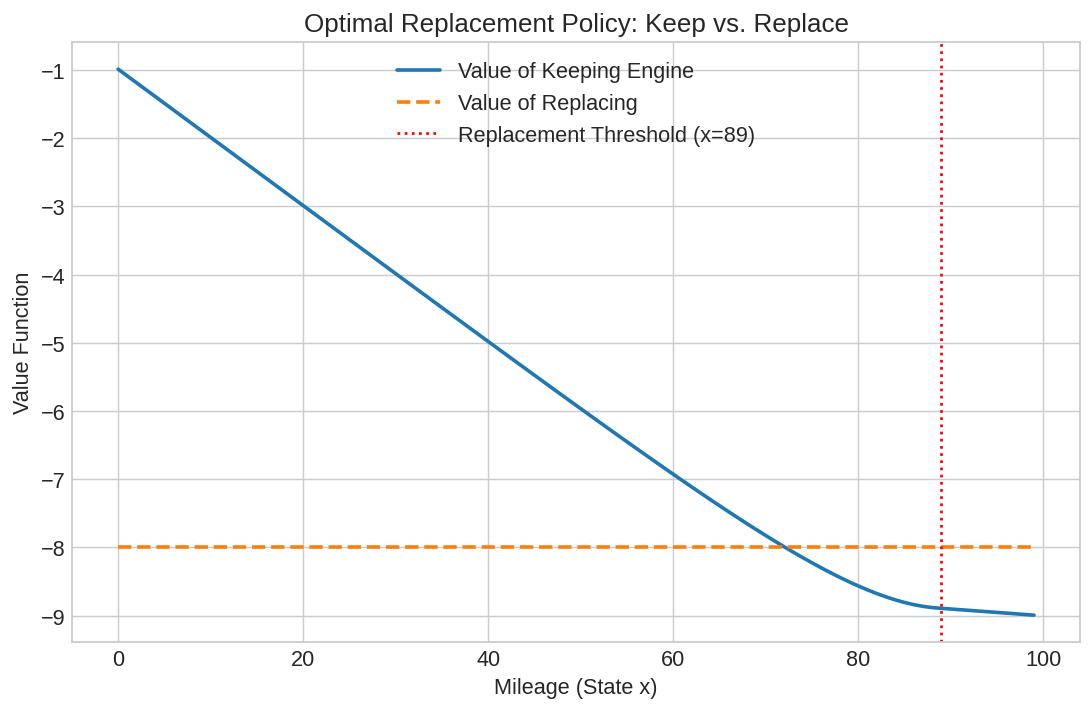

In [3]:
### Visualizing the Optimal Policy

plt.figure(figsize=(10, 6))
plt.plot(model.state_grid, v_keep, label='Value of Keeping Engine', linewidth=2)
plt.plot(model.state_grid, np.full_like(model.state_grid, v_replace), label='Value of Replacing', linestyle='--', linewidth=2)
plt.axvline(x=threshold_state, color='red', linestyle=':', label=f'Replacement Threshold (x={threshold_state})')

plt.title('Optimal Replacement Policy: Keep vs. Replace')
plt.xlabel('Mileage (State x)')
plt.ylabel('Value Function')
plt.legend()
plt.show()

# Summary

This part showed how discrete choices create nested value functions and how Rust-style optimal replacement problems are solved using conditional value functions.
